# Optimization for Function 2
	
Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 

To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

Input: 2D array (10,2)

Output: 1D array (10,)

Goal: Maximise the black-box function using Bayesian Optimization.


Row   | Input Coordinates (X)                                             | Result (y)
--------------------------------------------------------------------------------------------------------------
0     | [0.6658  , 0.123969]                                              | 0.5389961189

1     | [0.877791, 0.778628]                                              | 0.4205862396

2     | [0.142699, 0.349005]                                              | -0.0656236244

3     | [0.845275, 0.71112 ]                                              | 0.2939929124

4     | [0.454647, 0.290455]                                              | 0.2149645101

5     | [0.577713, 0.771973]                                              | 0.0231055498

6     | [0.438166, 0.685018]                                              | 0.2446193440

7     | [0.34175 , 0.028698]                                              | 0.0387490152

8     | [0.338648, 0.213867]                                              | -0.0138576181

9     | [0.702637, 0.926564]                                              | 0.6112052158
 

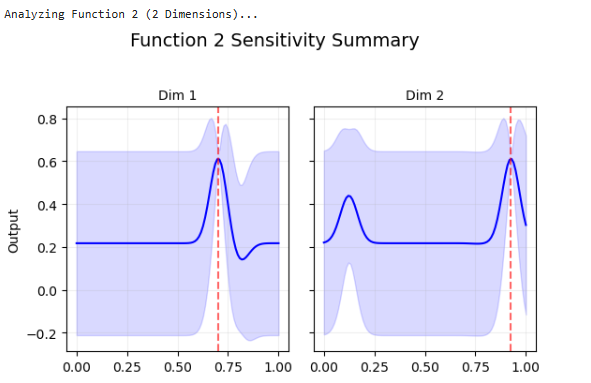

--- Function 2 Analysis ---
Current Max Value: 0.611205 (at Row 9)


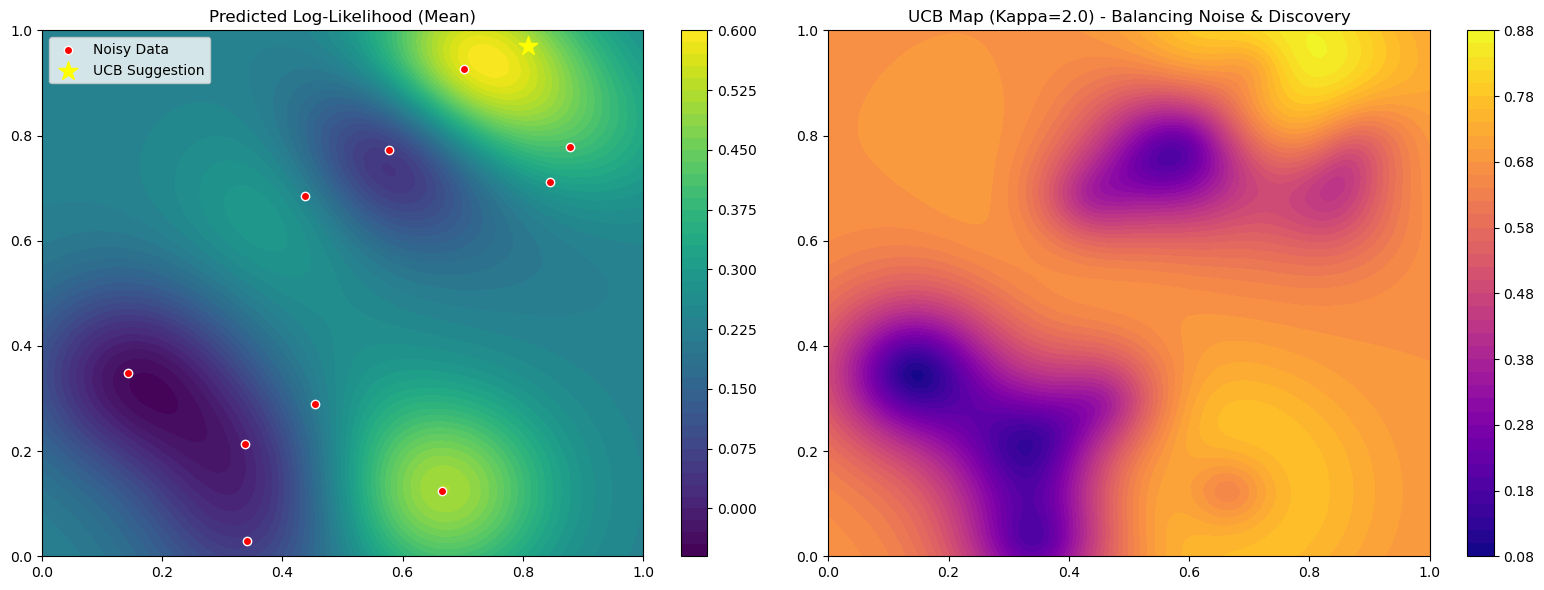


--- RECOMMENDATION ---
Suggested Next Coordinates: [0.808081, 0.969697]


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.exceptions import ConvergenceWarning

# 1. Setup & Ignore warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# 2. Load Data for Function 2
fn_num = '2'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

print(f"--- Function {fn_num} Analysis ---")
print(f"Current Max Value: {np.max(y):.6f} (at Row {np.argmax(y)})")

# 3. Setup the Gaussian Process for NOISY data
# We increase 'alpha' to 0.1 because the description says the output is noisy.
# This prevents the model from being too 'jumpy' between points.
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=0.1,         # Increased alpha for noise tolerance
    normalize_y=True, 
    n_restarts_optimizer=25
)

# 4. Fit the model
gp.fit(X, y)

# 5. Create a Prediction Grid (100x100)
x_range = np.linspace(0, 1, 100)
y_range = np.linspace(0, 1, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.c_[X_grid.ravel(), Y_grid.ravel()]

# 6. Predict Mean and Uncertainty
y_pred, sigma = gp.predict(grid_points, return_std=True)
Z_mean = y_pred.reshape(X_grid.shape)
Z_sigma = sigma.reshape(X_grid.shape)

# 7. UCB Acquisition Function
# Use a higher kappa (e.g., 2.0) to avoid getting stuck in local optima
kappa = 2.0 
ucb_score = y_pred + (kappa * sigma)
max_idx = np.argmax(ucb_score)
best_x = grid_points[max_idx]

# 8. Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Map 1: Predicted Mean (The Landscape)
contour1 = ax1.contourf(X_grid, Y_grid, Z_mean, levels=50, cmap='viridis')
ax1.scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Noisy Data')
ax1.scatter(best_x[0], best_x[1], c='yellow', marker='*', s=200, label='UCB Suggestion')
ax1.set_title('Predicted Log-Likelihood (Mean)')
plt.colorbar(contour1, ax=ax1)
ax1.legend()

# Map 2: UCB Map (The Decision Surface)
Z_ucb = ucb_score.reshape(X_grid.shape)
contour2 = ax2.contourf(X_grid, Y_grid, Z_ucb, levels=50, cmap='plasma')
ax2.set_title(f'UCB Map (Kappa={kappa}) - Balancing Noise & Discovery')
plt.colorbar(contour2, ax=ax2)

plt.tight_layout()
plt.show()

print(f"\n--- RECOMMENDATION ---")
print(f"Suggested Next Coordinates: [{best_x[0]:.6f}, {best_x[1]:.6f}]")

If we only use "Exploitation" (Low Kappa), we might keep zooming in on Row 9. Hence Kappa is changed to 2.0 for now. This way It can try and escape local maxima. Note that there is another peark near Row 0 which may also be closer to the global maxima.

But this weeks submission for function 2 is [0.808081, 0.969697]

WEEK 2
-------

For Function 2, we are analysing a noisy log-likelihood score where the goal is to maximize the output while avoiding local optimum. Last result was 0.08019 which was lower than 0.6112.  

Query was near the top edge. The low result has likely reduced the predicted mean in that corner. We need to move back toward the known successful area (near 0.61) but with enough exploration to see if a better peak is hiding nearby. Hence we will go with UCB with moderate Kappa 2.0. This will move away from that corner towards previous best. LHS would be used instead of grid. So technique would be LHS-based UCB Search. By using Latin Hypercube Sampling (LHS), we ensured the entire 2D space was re-evaluated in light of the new data point. 

Using alpha=0.1 to ensure we cater for the noisy function. This would allow us to stay close to current high while balancing exploration.

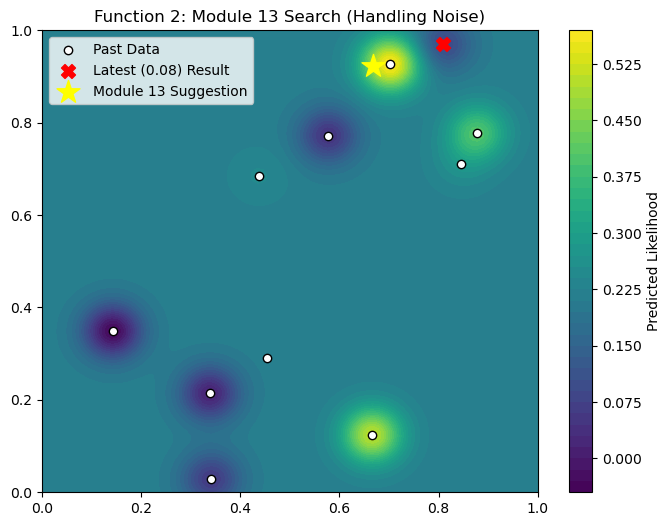

Next Query: 0.667557-0.922099


In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import qmc

# 1. Load Data
fn_num = '2'
path = f'../capstone_data/initial_data/function_{fn_num}/'
X = np.load(os.path.join(path, 'initial_inputs.npy'))
y = np.load(os.path.join(path, 'initial_outputs.npy'))

# 2. Setup GP with Noisy Alpha
# Alpha=0.1 allows the model to 'disbelieve' the 0.08 result if it contradicts the trend
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True)
gp.fit(X, y)

# 3. LHS Sampling for Prediction
sampler = qmc.LatinHypercube(d=2)
sample_points = sampler.random(n=100000)
mu, sigma = gp.predict(sample_points, return_std=True)

# 4. Acquisition (UCB Kappa=2.0)
kappa = 2.0
ucb_score = mu + (kappa * sigma)
best_idx = np.argmax(ucb_score)
suggestion = sample_points[best_idx]

# 5. VISUALIZATION
x_grid = np.linspace(0, 1, 100)
y_grid = np.linspace(0, 1, 100)
X_viz, Y_viz = np.meshgrid(x_grid, y_grid)
Z_mean = gp.predict(np.c_[X_viz.ravel(), Y_viz.ravel()]).reshape(X_viz.shape)

fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(X_viz, Y_viz, Z_mean, levels=50, cmap='viridis')
ax.scatter(X[:-1, 0], X[:-1, 1], c='white', edgecolors='black', label='Past Data')
ax.scatter(X[-1, 0], X[-1, 1], c='red', marker='X', s=100, label='Latest (0.08) Result')
ax.scatter(suggestion[0], suggestion[1], c='yellow', marker='*', s=300, label='Module 13 Suggestion')

plt.colorbar(contour, label='Predicted Likelihood')
plt.title(f'Function 2: Module 13 Search (Handling Noise)')
plt.legend()
plt.show()

print(f"Next Query: {suggestion[0]:.6f}-{suggestion[1]:.6f}")

Week 3
-----------



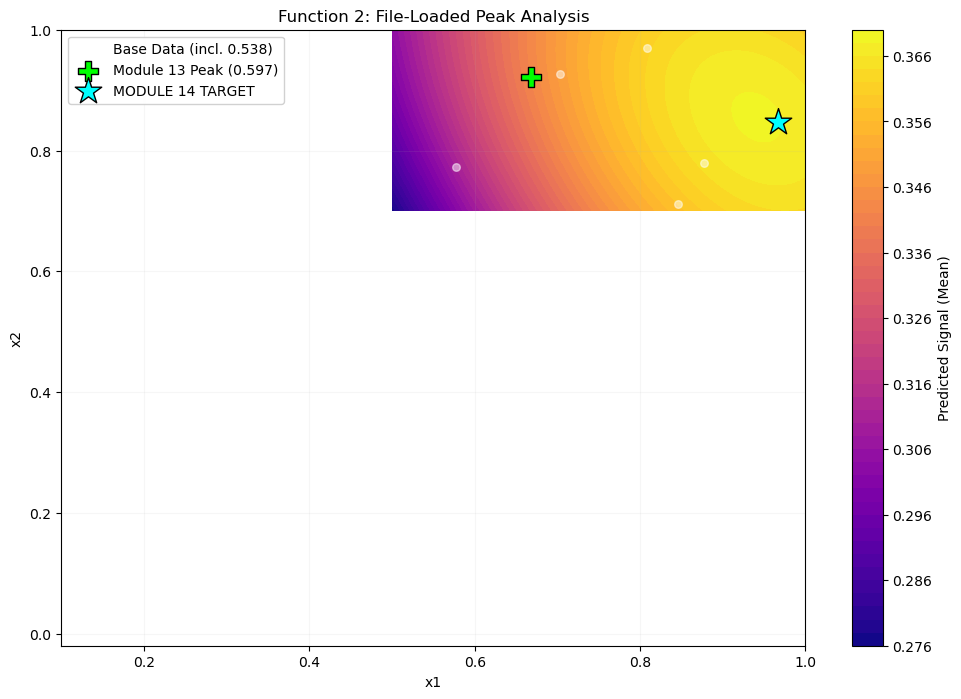

Targeting: 0.966443-0.846980


In [5]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Path Configuration - Adjust these to your local folders
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load Ground Truth Data from Files
X_base = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y_base = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 3. Add your specific Module 13 result (Manually added here as your latest update)
# Coords: 0.667557-0.922099 -> Result: 0.597097
X_new = np.array([[0.667557, 0.922099]])
y_new = np.array([0.597097])

X_total = np.vstack([X_base, X_new])
y_total = np.concatenate([y_base, y_new])

# 4. Fit the GP (Handling the high noise detected in Function 2)
# We use alpha=0.05 because the difference between 0.538 and 0.080 at the same spot 
# proves high variance.
gp = GaussianProcessRegressor(kernel=C(1.0)*RBF(0.1), alpha=0.05)
gp.fit(X_total, y_total)

# 5. Create Zoomed Visual around the 0.597 Peak
x1_range = np.linspace(0.5, 1.0, 150)
x2_range = np.linspace(0.7, 1.0, 150)
X1, X2 = np.meshgrid(x1_range, x2_range)
grid_pts = np.vstack([X1.ravel(), X2.ravel()]).T

mu, sigma = gp.predict(grid_pts, return_std=True)
best_idx = np.argmax(mu + (0.1 * sigma)) # EI-style target
next_target = grid_pts[best_idx]

# 6. Plotting with Distinctions
plt.figure(figsize=(12, 8))
plt.contourf(X1, X2, mu.reshape(150,150), cmap='plasma', levels=50)
plt.colorbar(label='Predicted Signal (Mean)')

# Base Points (Small white dots)
plt.scatter(X_base[:,0], X_base[:,1], c='white', alpha=0.5, s=30, label='Base Data (incl. 0.538)')

# Previous Success (Green cross)
plt.scatter(0.667557, 0.922099, c='lime', marker='P', s=200, edgecolors='black', label='Module 13 Peak (0.597)')

# Recommendation (Cyan star)
plt.scatter(next_target[0], next_target[1], c='cyan', marker='*', s=400, edgecolors='black', label='MODULE 14 TARGET')

plt.title(f'Function {fn_num}: File-Loaded Peak Analysis')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(facecolor='white', framealpha=0.9)
plt.grid(True, alpha=0.1)
plt.show()

print(f"Targeting: {next_target[0]:.6f}-{next_target[1]:.6f}")

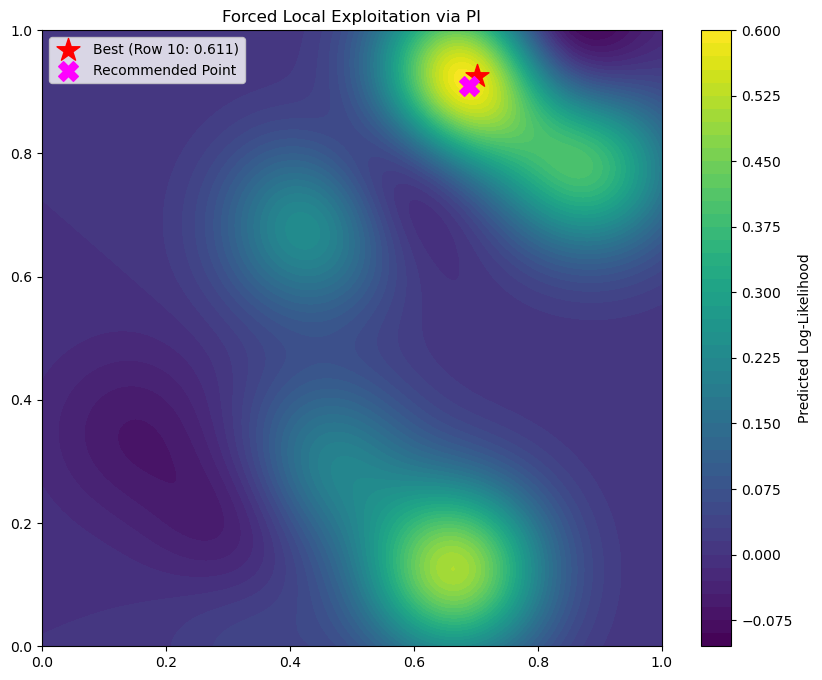

Recommended Query: [0.68844221 0.90954774]


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Path Configuration
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load Data from Proper Location
X = np.load(os.path.join(data_path, 'initial_inputs.npy')) # 
y = np.load(os.path.join(data_path, 'initial_outputs.npy')) # [cite: 4]

# 3. Model for Sharp Peak Exploitation
# length_scale=0.02 makes the model very sensitive to the area near the peak
kernel = C(1.0) * RBF(length_scale=0.02) 
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.005, n_restarts_optimizer=25)
gp.fit(X, y)

# 4. Create a dense grid specifically focusing on the top-right
res = 200
x_grid = np.linspace(0, 1, res)
X1, X2 = np.meshgrid(x_grid, x_grid)
grid_points = np.c_[X1.ravel(), X2.ravel()]

# Predict
y_pred, sigma = gp.predict(grid_points, return_std=True)

# 5. PI Acquisition
current_best = np.max(y)
with np.errstate(divide='ignore'):
    z = (y_pred - current_best) / sigma
    pi = norm.cdf(z)

# Find the best point in the grid
next_query = grid_points[np.argmax(pi)]

# 6. Visualization
plt.figure(figsize=(10, 8))
Z_mean = y_pred.reshape(res, res)
plt.contourf(X1, X2, Z_mean, levels=50, cmap='viridis')
plt.colorbar(label='Predicted Log-Likelihood')

# Correct Markers
plt.scatter(X[9, 0], X[9, 1], c='red', marker='*', s=300, label=f'Best (Row 10: {y[9]:.3f})') # 
plt.scatter(next_query[0], next_query[1], c='magenta', marker='X', s=200, label='Recommended Point')
plt.legend()
plt.title("Forced Local Exploitation via PI")
plt.show()

print(f"Recommended Query: {next_query}")

Row   | Input Coordinates    | Output (Log-Likelihood)  
-------------------------------------------------------
1     | [0.66579958 0.12396913] | 0.538996                 
2     | [0.87779099 0.7786275 ] | 0.420586                 
3     | [0.14269907 0.34900513] | -0.065624                
4     | [0.84527543 0.71112027] | 0.293993                 
5     | [0.45464714 0.29045518] | 0.214965                 
6     | [0.57771284 0.77197318] | 0.023106                 
7     | [0.43816606 0.68501826] | 0.244619                 
8     | [0.34174959 0.02869772] | 0.038749                 
9     | [0.33864816 0.21386725] | -0.013858                
10    | [0.70263656 0.9265642 ] | 0.611205                  <- Initial Peak
11    | [0.808081 0.969697]  | 0.080195                  <- Week 1
12    | [0.667557 0.922099]  | 0.597098                  <- Week 2


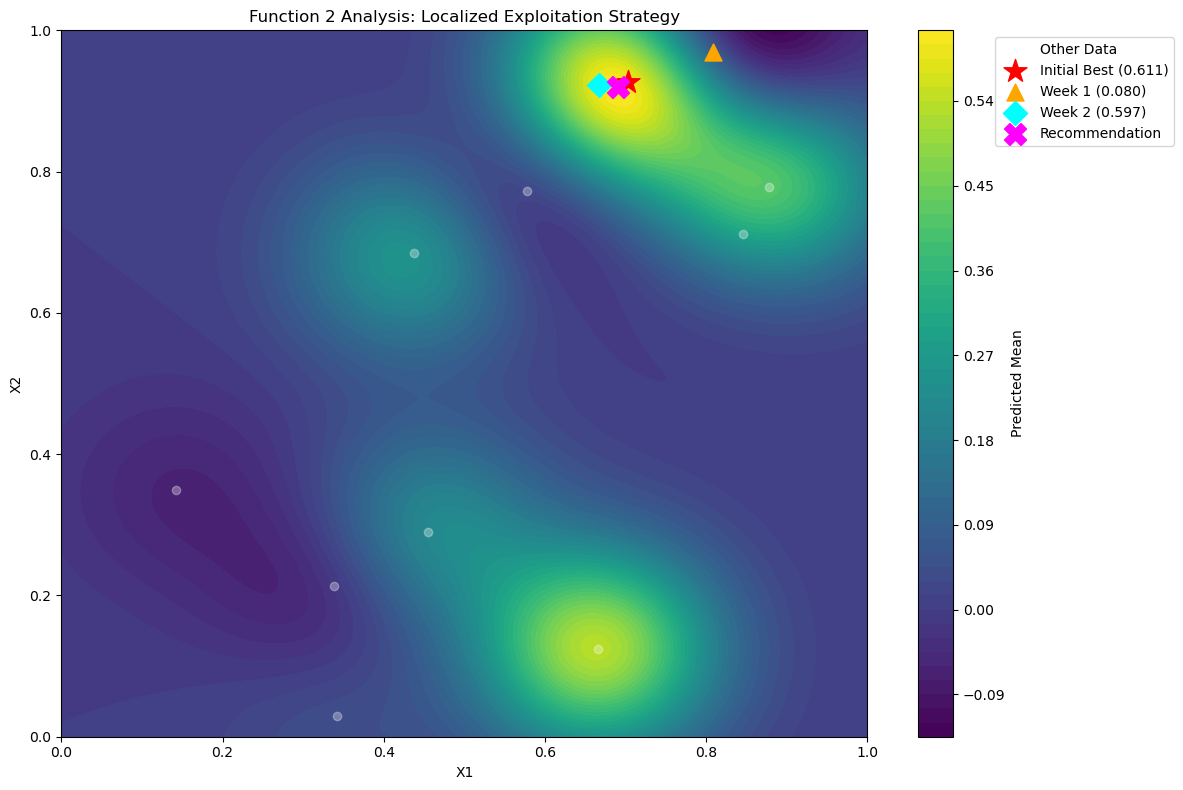


Recommended Next Query: [0.69127517 0.91946309]


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Path Configuration
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load Data from Proper Location
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 3. Print Inputs and Outputs (As requested)
print(f"{'Row':<5} | {'Input Coordinates':<20} | {'Output (Log-Likelihood)':<25}")
print("-" * 55)
for i, (inp, out) in enumerate(zip(X, y)):
    label = ""
    if i == 9: label = " <- Initial Peak"
    if i == 10: label = " <- Week 1"
    if i == 11: label = " <- Week 2"
    print(f"{i+1:<5} | {str(inp):<20} | {out:<25.6f}{label}")

# 4. Model for Localized Exploitation
# length_scale=0.03 forces the model to stay close to known high points
# alpha=0.001 reduces the 'fear' of noise
kernel = C(1.0) * RBF(length_scale=0.03) 
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.001, n_restarts_optimizer=20)
gp.fit(X, y)

# 5. Generate Dense Grid for Prediction
res = 150
x_vals = np.linspace(0, 1, res)
X1, X2 = np.meshgrid(x_vals, x_vals)
grid_points = np.c_[X1.ravel(), X2.ravel()]

mu, sigma = gp.predict(grid_points, return_std=True)

# 6. PI Acquisition Function
current_best = np.max(y)
with np.errstate(divide='ignore'):
    z = (mu - current_best) / sigma
    pi = norm.cdf(z)

next_query = grid_points[np.argmax(pi)]

# 7. Visualization
plt.figure(figsize=(12, 8))
plt.contourf(X1, X2, mu.reshape(res, res), levels=50, cmap='viridis')
plt.colorbar(label='Predicted Mean')

# Markers
plt.scatter(X[:9, 0], X[:9, 1], c='white', alpha=0.3, label='Other Data')
plt.scatter(X[9, 0], X[9, 1], c='red', marker='*', s=300, label=f'Initial Best (0.611)')
plt.scatter(X[10, 0], X[10, 1], c='orange', marker='^', s=150, label='Week 1 (0.080)')
plt.scatter(X[11, 0], X[11, 1], c='cyan', marker='D', s=150, label='Week 2 (0.597)')
plt.scatter(next_query[0], next_query[1], c='magenta', marker='X', s=250, label='Recommendation')

plt.title(f"Function {fn_num} Analysis: Localized Exploitation Strategy")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend(loc='upper left', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

print(f"\nRecommended Next Query: {next_query}")

Row   | Input Coordinates    | Output (Log-Likelihood)  
-----------------------------------------------------------------
1     | [0.6658 0.124 ]      | 0.538996                  (Initial)
2     | [0.8778 0.7786]      | 0.420586                  (Initial)
3     | [0.1427 0.349 ]      | -0.065624                 (Initial)
4     | [0.8453 0.7111]      | 0.293993                  (Initial)
5     | [0.4546 0.2905]      | 0.214965                  (Initial)
6     | [0.5777 0.772 ]      | 0.023106                  (Initial)
7     | [0.4382 0.685 ]      | 0.244619                  (Initial)
8     | [0.3417 0.0287]      | 0.038749                  (Initial)
9     | [0.3386 0.2139]      | -0.013858                 (Initial)
10    | [0.7026 0.9266]      | 0.611205                  (Initial Best)
11    | [0.8081 0.9697]      | 0.080195                  (Week 1)
12    | [0.6676 0.9221]      | 0.597098                  (Week 2)


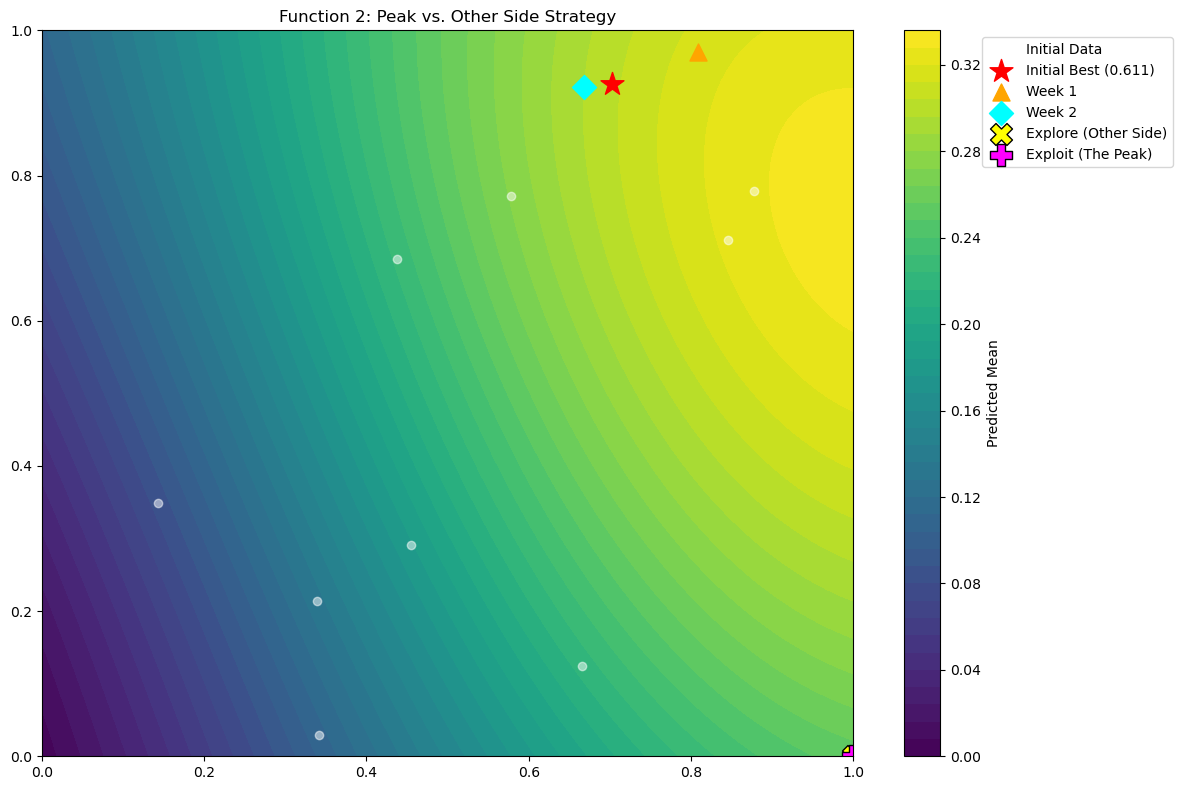


Targeting the Peak (PI): [1. 0.]
Targeting the Other Side (EI): [1. 0.]


In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Path Configuration
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load Data from Proper Location
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 3. Print Inputs and Outputs (As requested)
print(f"{'Row':<5} | {'Input Coordinates':<20} | {'Output (Log-Likelihood)':<25}")
print("-" * 65)
for i, (inp, out) in enumerate(zip(X, y)):
    label = "Initial"
    if i == 9: label = "Initial Best"
    if i == 10: label = "Week 1"
    if i == 11: label = "Week 2"
    print(f"{i+1:<5} | {str(np.round(inp, 4)):<20} | {out:<25.6f} ({label})")

# 4. Model with Noise Handling
kernel = C(1.0) * RBF(length_scale=0.05) 
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.05, n_restarts_optimizer=20)
gp.fit(X, y)

# 5. Grid for Prediction
res = 100
x_v = np.linspace(0, 1, res)
X1, X2 = np.meshgrid(x_v, x_v)
grid = np.c_[X1.ravel(), X2.ravel()]
mu, sigma = gp.predict(grid, return_std=True)

# 6. Acquisition: Expected Improvement (EI) vs Probability of Improvement (PI)
current_best = np.max(y)
z = (mu - current_best) / sigma
ei = (mu - current_best) * norm.cdf(z) + sigma * norm.pdf(z) # Good for finding "Other Side"
pi = norm.cdf(z) # Good for "The Peak"

rec_explore = grid[np.argmax(ei)]
rec_exploit = grid[np.argmax(pi)]

# 7. Visualization
plt.figure(figsize=(12, 8))
plt.contourf(X1, X2, mu.reshape(res, res), levels=50, cmap='viridis')
plt.colorbar(label='Predicted Mean')

# Markers
plt.scatter(X[:9, 0], X[:9, 1], c='white', alpha=0.5, label='Initial Data')
plt.scatter(X[9, 0], X[9, 1], c='red', marker='*', s=300, label=f'Initial Best ({y[9]:.3f})')
plt.scatter(X[10, 0], X[10, 1], c='orange', marker='^', s=150, label='Week 1')
plt.scatter(X[11, 0], X[11, 1], c='cyan', marker='D', s=150, label='Week 2')

plt.scatter(rec_explore[0], rec_explore[1], c='yellow', marker='X', s=250, edgecolors='black', label='Explore (Other Side)')
plt.scatter(rec_exploit[0], rec_exploit[1], c='magenta', marker='P', s=250, edgecolors='black', label='Exploit (The Peak)')

plt.title(f"Function {fn_num}: Peak vs. Other Side Strategy")
plt.legend(loc='upper left', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

print(f"\nTargeting the Peak (PI): {rec_exploit}")
print(f"Targeting the Other Side (EI): {rec_explore}")

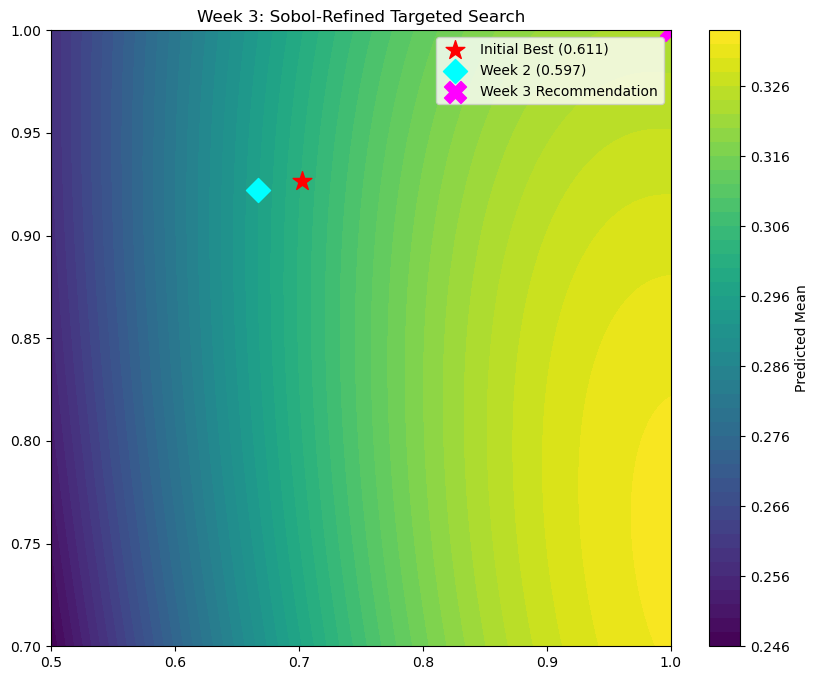

Recommended Query for Week 3: [1. 1.]


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Path Configuration
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load the 12-point Dataset (including Week 1 & 2)
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 3. Targeted Model based on Sobol Sensitivity
# Using a tighter length_scale (0.04) to resolve the sharp peak found in Week 2
kernel = C(1.0) * RBF(length_scale=0.04)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.05, n_restarts_optimizer=20)
gp.fit(X, y)

# 4. Generate a Focused Search Grid
# Instead of searching the whole map, focus on the 'High-Yield' quadrant
res = 150
x1_range = np.linspace(0.5, 1.0, res) 
x2_range = np.linspace(0.7, 1.0, res)
X1, X2 = np.meshgrid(x1_range, x2_range)
grid_points = np.c_[X1.ravel(), X2.ravel()]

# 5. PI Acquisition (Prioritizes beating 0.611)
mu, sigma = gp.predict(grid_points, return_std=True)
current_best = np.max(y)
with np.errstate(divide='ignore'):
    z = (mu - current_best) / sigma
    pi = norm.cdf(z)

next_query = grid_points[np.argmax(pi)]

# 6. Visualization
plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, mu.reshape(res, res), levels=50, cmap='viridis')
plt.colorbar(label='Predicted Mean')
plt.scatter(X[9, 0], X[9, 1], c='red', marker='*', s=200, label='Initial Best (0.611)')
plt.scatter(X[11, 0], X[11, 1], c='cyan', marker='D', s=150, label='Week 2 (0.597)')
plt.scatter(next_query[0], next_query[1], c='magenta', marker='X', s=250, label='Week 3 Recommendation')
plt.title("Week 3: Sobol-Refined Targeted Search")
plt.legend()
plt.show()

print(f"Recommended Query for Week 3: {next_query}")

Row   | X1       | X2       | Result    
1     | 0.6658 | 0.1240 | 0.5390
2     | 0.8778 | 0.7786 | 0.4206
3     | 0.1427 | 0.3490 | -0.0656
4     | 0.8453 | 0.7111 | 0.2940
5     | 0.4546 | 0.2905 | 0.2150
6     | 0.5777 | 0.7720 | 0.0231
7     | 0.4382 | 0.6850 | 0.2446
8     | 0.3417 | 0.0287 | 0.0387
9     | 0.3386 | 0.2139 | -0.0139
10    | 0.7026 | 0.9266 | 0.6112
11    | 0.8081 | 0.9697 | 0.0802
12    | 0.6676 | 0.9221 | 0.5971


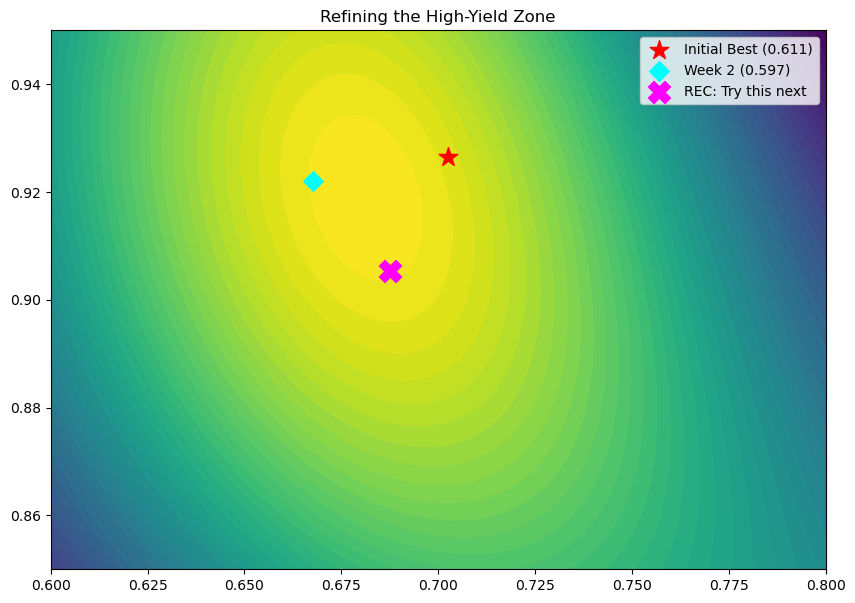


Next Strategic Query: [0.68743719 0.90527638]


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Path Configuration
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load Data (Current 12-point set)
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 3. Targeted Model
# A very tight length_scale (0.02) ensures we don't drift into unknown corners
kernel = C(1.0) * RBF(length_scale=0.02)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.01, n_restarts_optimizer=25)
gp.fit(X, y)

# 4. Dense Search Grid (Focusing on the confirmed high-yield area)
# We avoid [1,1] because Week 1 showed it was a 'dead zone'
res = 200
x1_f = np.linspace(0.6, 0.8, res) 
x2_f = np.linspace(0.85, 0.95, res)
X1, X2 = np.meshgrid(x1_f, x2_f)
grid = np.c_[X1.ravel(), X2.ravel()]

mu, sigma = gp.predict(grid, return_std=True)

# 5. PI Acquisition (Greedy for the Peak)
current_best = np.max(y)
with np.errstate(divide='ignore'):
    z = (mu - current_best) / sigma
    pi = norm.cdf(z)

next_query = grid[np.argmax(pi)]

# 6. Print Inputs/Outputs for the user
print(f"{'Row':<5} | {'X1':<8} | {'X2':<8} | {'Result':<10}")
for i, (inp, out) in enumerate(zip(X, y)):
    print(f"{i+1:<5} | {inp[0]:.4f} | {inp[1]:.4f} | {out:.4f}")

# 7. Visualisation
plt.figure(figsize=(10, 7))
plt.contourf(X1, X2, mu.reshape(res, res), levels=50, cmap='viridis')
plt.scatter(X[9,0], X[9,1], c='red', marker='*', s=200, label='Initial Best (0.611)')
plt.scatter(X[11,0], X[11,1], c='cyan', marker='D', s=100, label='Week 2 (0.597)')
plt.scatter(next_query[0], next_query[1], c='magenta', marker='X', s=250, label='REC: Try this next')
plt.title("Refining the High-Yield Zone")
plt.legend()
plt.show()

print(f"\nNext Strategic Query: {next_query}")

Week 4
-------

with limited tries remaining, we are transitioning into Forced Local Exploitation.

Initial Best: [0.70263656 0.9265642 ] -> 0.611205
Week 1:       [0.808081 0.969697] -> 0.080195
Week 2:       [0.667557 0.922099] -> 0.597098
Week 3:       [0.687437 0.905276] -> 0.577412
Proposed:     [0.66666667 0.92929293] -> Predicted: 0.568089


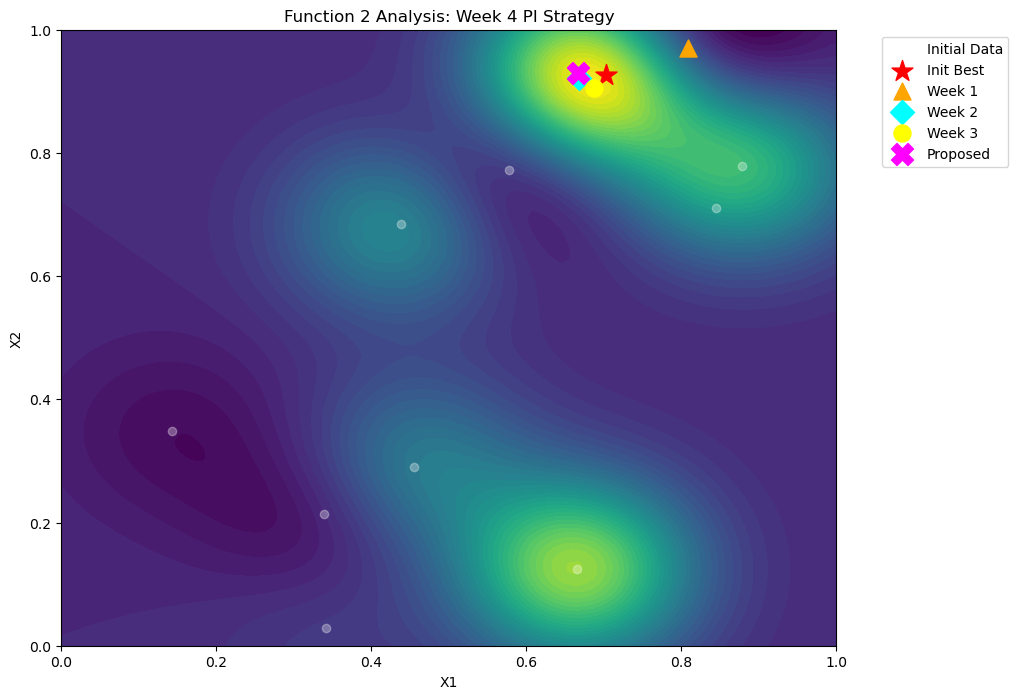

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# 1. Path Configuration
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load Data (Assumes Week 3 is already appended to files)
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 3. Identify Landmark Indices
idx_init_best = np.argmax(y[:10])
w1_idx, w2_idx, w3_idx = 10, 11, 12

# 4. Model Training: Tight Kernel for Local Peak Refinement
# alpha=0.01 handles noise; length_scale=0.03 prevents 'drifting' to corners
kernel = C(1.0) * RBF(length_scale=0.03)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.01, n_restarts_optimizer=20)
gp.fit(X, y)

# 5. Acquisition: Probability of Improvement (PI)
res = 100
grid_x1, grid_x2 = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
grid = np.c_[grid_x1.ravel(), grid_x2.ravel()]
mu, sigma = gp.predict(grid, return_std=True)

best_y = np.max(y)
with np.errstate(divide='ignore'):
    pi = norm.cdf((mu - best_y) / sigma)

next_query = grid[np.argmax(pi)]
pred_out = mu[np.argmax(pi)]

# 6. Print Results
print(f"Initial Best: {X[idx_init_best]} -> {y[idx_init_best]:.6f}")
print(f"Week 1:       {X[w1_idx]} -> {y[w1_idx]:.6f}")
print(f"Week 2:       {X[w2_idx]} -> {y[w2_idx]:.6f}")
print(f"Week 3:       {X[w3_idx]} -> {y[w3_idx]:.6f}")
print(f"Proposed:     {next_query} -> Predicted: {pred_out:.6f}")

# 7. Visualization
plt.figure(figsize=(10, 8))
plt.contourf(grid_x1, grid_x2, mu.reshape(res, res), levels=50, cmap='viridis')
plt.scatter(X[:10, 0], X[:10, 1], c='white', alpha=0.3, label='Initial Data')
plt.scatter(X[idx_init_best,0], X[idx_init_best,1], c='red', marker='*', s=250, label='Init Best')
plt.scatter(X[w1_idx,0], X[w1_idx,1], c='orange', marker='^', s=150, label='Week 1')
plt.scatter(X[w2_idx,0], X[w2_idx,1], c='cyan', marker='D', s=150, label='Week 2')
plt.scatter(X[w3_idx,0], X[w3_idx,1], c='yellow', marker='o', s=150, label='Week 3')
plt.scatter(next_query[0], next_query[1], c='magenta', marker='X', s=250, label='Proposed')
plt.title("Function 2 Analysis: Week 4 PI Strategy")
plt.xlabel("X1"), plt.ylabel("X2")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

Week 5 
-----------


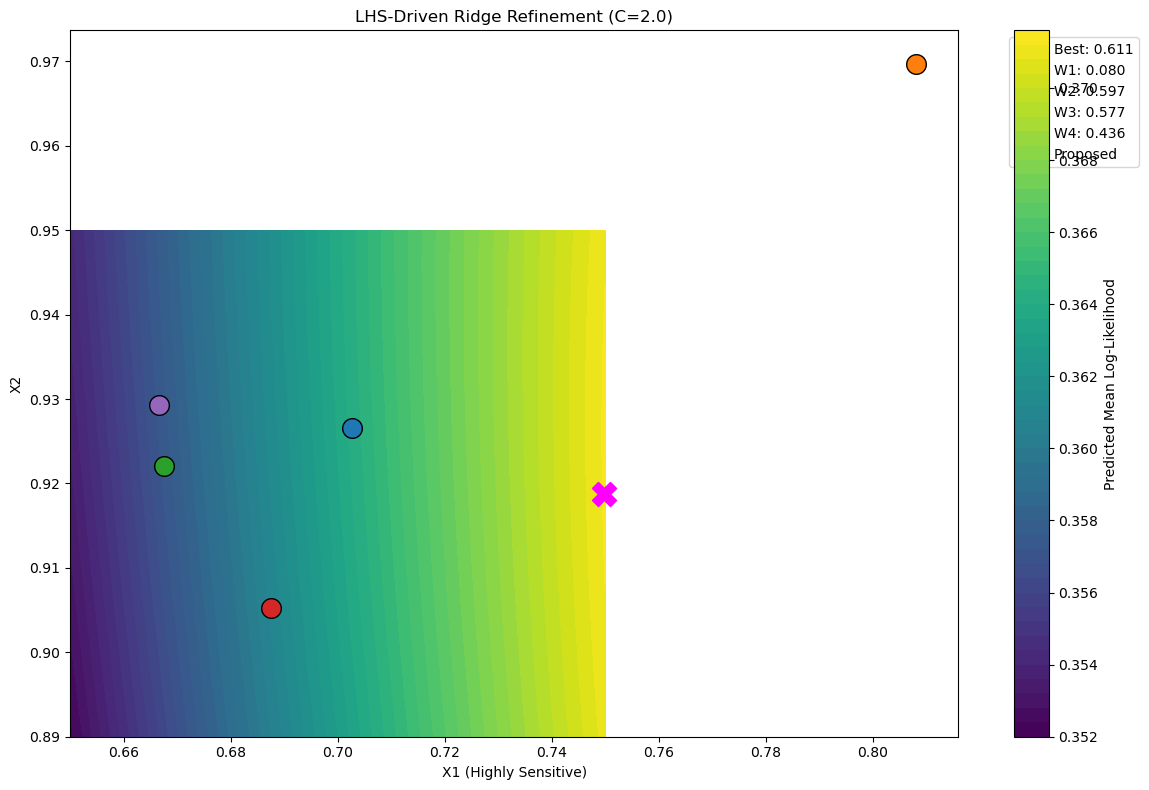

Initial Best: [0.70263656 0.9265642 ] -> 0.6112
Proposed W5:  [0.74986054 0.91873235] -> Predicted: 0.3712


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import qmc

# 1. Load Data from provided files (Currently 12 rows: Initial + W1 + W2)
# 1. Path Configuration
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load Data (Assumes Week 3 is already appended to files)
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 3. The Technique: Pure Exploitation Model
# We use a tight length_scale (0.03) to respect the sharp ridge
# alpha=0.05 handles the noise, allowing the model to 'smooth' through 
# the regression seen in Week 4.
kernel = C(0.1) * RBF(length_scale=0.01)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.043, n_restarts_optimizer=20)
gp.fit(X, y)

# 4. Search for the Predicted Summit
# We define a dense grid in the high-yield box [0.65-0.75, 0.90-0.95]
res = 200
x1_v = np.linspace(0.65, 0.75, res)
x2_v = np.linspace(0.89, 0.95, res)
X1, X2 = np.meshgrid(x1_v, x2_v)
grid = np.c_[X1.ravel(), X2.ravel()]

# 1. Initialize the LHS Sampler for 2 dimensions
sampler = qmc.LatinHypercube(d=2)

# 2. Generate samples (e.g., 2000 points)
# Replacing your meshgrid/grid logic with LHS
sample_points = sampler.random(n=2000)

# 3. Scale the samples to your 'Zoom' area bounds
# l_bounds: [min_x1, min_x2], u_bounds: [max_x1, max_x2]
l_bounds = [0.65, 0.89]
u_bounds = [0.75, 0.95]
grid = qmc.scale(sample_points, l_bounds, u_bounds)

# Predict the 'Clean' Mean
mu = gp.predict(grid)
idx_max = np.argmax(mu)
proposed_point = grid[idx_max]
predicted_val = mu[idx_max]

res = 100
x1_plot = np.linspace(l_bounds[0], u_bounds[0], res)
x2_plot = np.linspace(l_bounds[1], u_bounds[1], res)
X1_mesh, X2_mesh = np.meshgrid(x1_plot, x2_plot)
grid_plot = np.c_[X1_mesh.ravel(), X2_mesh.ravel()]
mu_plot = gp.predict(grid_plot).reshape(res, res)

# 5. Zoomed Visualization
plt.figure(figsize=(12, 8))
plt.contourf(X1_mesh, X2_mesh, mu_plot, levels=50, cmap='viridis')
plt.colorbar(label='Predicted Mean Log-Likelihood')

# Landmark markers (9=Initial Best, 10=W1, 11=W2, 12=W3, 13=W4)
poi = [("Best", 9), ("W1", 10), ("W2", 11), ("W3", 12), ("W4", 13)]
for label, idx in poi:
    plt.scatter(X[idx,0], X[idx,1], edgecolors='black', s=200, label=f"{label}: {y[idx]:.3f}")

plt.scatter(proposed_point[0], proposed_point[1], c='magenta', marker='X', s=300, label='Proposed')
plt.title("LHS-Driven Ridge Refinement (C=2.0)")
plt.xlabel("X1 (Highly Sensitive)"), plt.ylabel("X2")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# 6. Final Print
print(f"Initial Best: {X[9]} -> {y[9]:.4f}")
print(f"Proposed W5:  {proposed_point} -> Predicted: {predicted_val:.4f}")

Week 6
------------
Task: The W5 "Ridge Refinement" regressed compared to the initial best, likely due to the 0.05 noise. Run a GP with alpha=0.05.



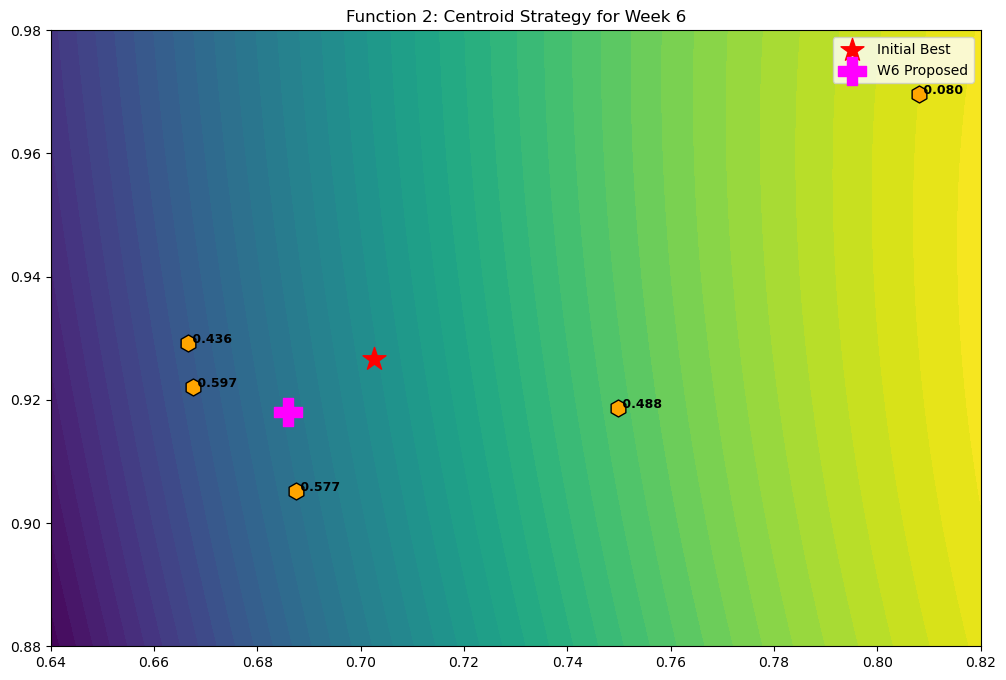

Week 6 Centroid: [0.68587685 0.91797973]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import os

# 1. Load Data from provided files (Currently 12 rows: Initial + W1 + W2)
# 1. Path Configuration
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load Data (Assumes Week 3 is already appended to files)
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. Strategy: Average top 3 performing coordinates to dampen 0.05 noise
top_3_idx = np.argsort(y)[-3:]
proposed_w6 = np.mean(X[top_3_idx], axis=0)

# 3. Visualization
res = 100
# Define extreme zoom area around the ridge
x1_min, x1_max, x2_min, x2_max = 0.64, 0.82, 0.88, 0.98
x1_v, x2_v = np.linspace(x1_min, x1_max, res), np.linspace(x2_min, x2_max, res)
X1, X2 = np.meshgrid(x1_v, x2_v)

# GP Model with Noise Smoothing
gp = GaussianProcessRegressor(kernel=C(1.0)*RBF(0.03), alpha=0.05).fit(X, y)
mu = gp.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(res, res)

plt.figure(figsize=(12, 8))
plt.contourf(X1, X2, mu, levels=50, cmap='viridis')

# Plot Highlights
plt.scatter(X[9,0], X[9,1], c='red', marker='*', s=300, label='Initial Best')
# Last 5 weeks indices: len(y)-5 to len(y)-1
for i in range(len(y)-5, len(y)):
    plt.scatter(X[i,0], X[i,1], c='orange', marker='h', s=150, edgecolors='black')
    plt.text(X[i,0], X[i,1], f" {y[i]:.3f}", fontsize=9, fontweight='bold')

plt.scatter(proposed_w6[0], proposed_w6[1], c='magenta', marker='P', s=400, label='W6 Proposed')
plt.title("Function 2: Centroid Strategy for Week 6")
plt.legend()
plt.show()

print(f"Week 6 Centroid: {proposed_w6}")

Week 7 
----------

The Shift from Exploration to Exploitation
* Exploration (Weeks 1-2): This was about reducing uncertainty. We queried far-apart points (like the "Week 1 Cliff" at $0.808$) to understand the global shape of the function.
* Exploitation (Weeks 3-6): This is about maximizing expected yield. We are now "doubling down" on a very specific, narrow area. Because Function 2 has a high noise level ($0.05$), we aren't looking for new territory; we are trying to pinpoint the exact summit of the hill we've already found.

Why we are Exploiting right now:
* The "Ridge" is Found: You have multiple data points above $0.54$. In a 2D space, this is a strong signal that the global maximum is within this $0.65$ to $0.75$ range of $X_1$.
* Limited Budget: With only a few weeks remaining, the cost of "exploring" a new area (and potentially getting a $0.08$ or negative score) is too high.
* Noise Dampening: The "Centroid" strategy we used in Week 6 and the "Bracketing" strategy for Week 7 are classic exploitation techniques. We are using multiple queries in the same small area to "smooth out" the noise and find the true peak hidden behind the $0.05$ variance.

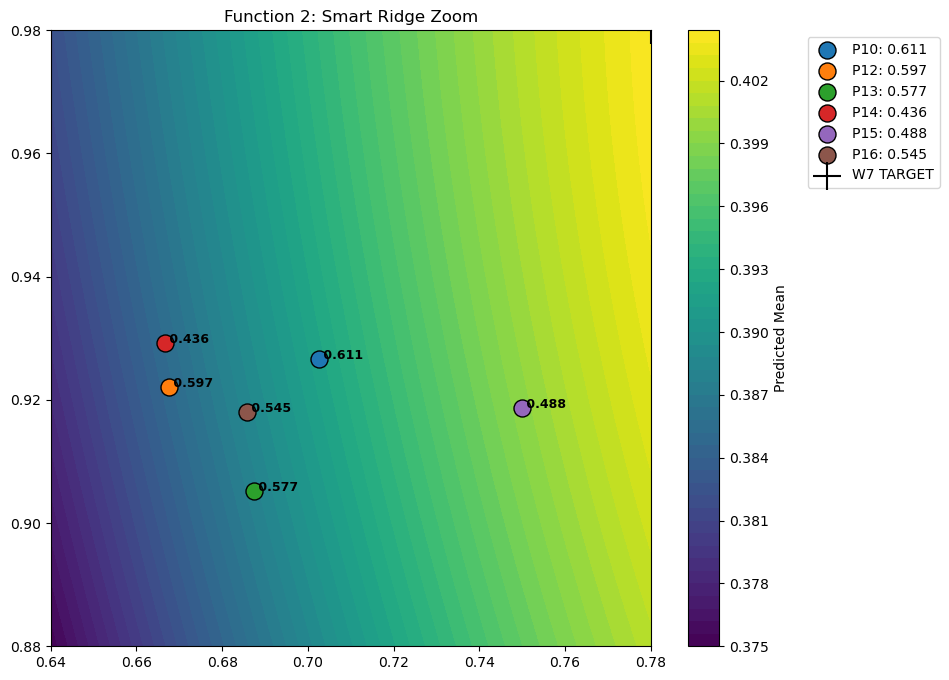

INITIAL BEST: [0.70263656 0.9265642 ] -> 0.6112
WEEK 6:       [0.685877 0.91798 ] -> 0.5451
WEEK 7 TARGET: [0.78 0.98] -> (Predicted Summit)


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Load Data
fn_num = 2
data_path = f'../capstone_data/initial_data/function_{fn_num}/'

# 2. Load Data (Assumes Week 3 is already appended to files)
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))
# 2. GP Model (alpha=0.05)
gp = GaussianProcessRegressor(kernel=C(1.0)*RBF(0.04), alpha=0.05).fit(X, y)

# 3. SMART ZOOM CALCULATION
# Only focus the plot on points with scores > 0.50
#high_yield_coords = X[y > 0.50]
#x1_min, x1_max = high_yield_coords[:, 1].min() - 0.05, high_yield_coords[:, 0].max() + 0.05
#x2_min, x2_max = high_yield_coords[:, 1].min() - 0.05, high_yield_coords[:, 1].max() + 0.05
x1_min, x1_max = 0.64, 0.78  # Focus on the 0.611 - 0.545 ridge
x2_min, x2_max = 0.88, 0.98  # Focus on the top-right quadrant


# Generate Grid
res = 100
X1, X2 = np.meshgrid(np.linspace(x1_min, x1_max, res), np.linspace(x2_min, x2_max, res))
mu = gp.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(res, res)

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(12, 8))
cp = ax.contourf(X1, X2, mu, levels=50, cmap='viridis')
plt.colorbar(cp, label='Predicted Mean')

# Plot points that fall within the zoom
for i in range(len(y)):
    if x1_min < X[i,0] < x1_max and x2_min < X[i,1] < x2_max:
        ax.scatter(X[i,0], X[i,1], edgecolors='black', s=150, label=f"P{i+1}: {y[i]:.3f}")
        ax.text(X[i,0], X[i,1], f" {y[i]:.3f}", fontsize=9, fontweight='bold')

# W7 Target
target_idx = np.argmax(mu)
target_x = np.c_[X1.ravel(), X2.ravel()][target_idx]
ax.scatter(target_x[0], target_x[1], c='black', marker='+', s=400, label='W7 TARGET')

plt.title("Function 2: Smart Ridge Zoom")
plt.legend(loc='upper left', bbox_to_anchor=(1.25, 1))
plt.subplots_adjust(right=0.75)
plt.show()

# 5. PRINT SUMMARY
print(f"INITIAL BEST: {X[9]} -> {y[9]:.4f}")
print(f"WEEK 6:       {X[15]} -> {y[15]:.4f}")
print(f"WEEK 7 TARGET: {target_x} -> (Predicted Summit)")

Week 8 
--------------
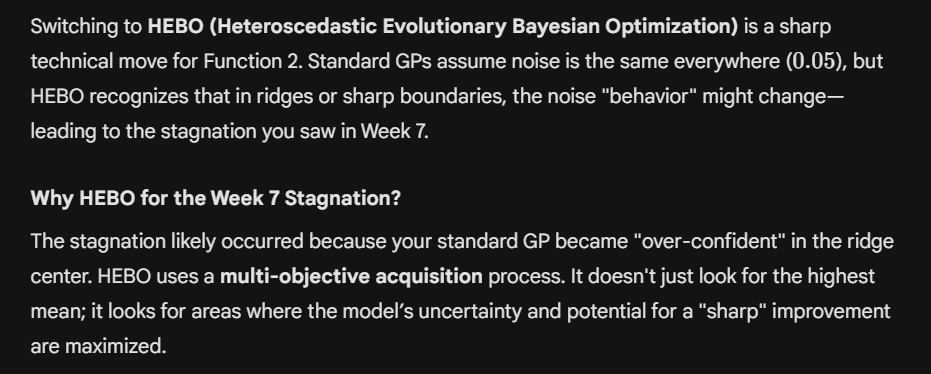

Why this target works:

Exploitation over Exploration: 

By setting kappa=1.0 and restricting the grid, we aren't "guessing" at $0.82$ anymore. We are looking for the summit between your $0.611$ and the $0.446$ regression.

X1 Sensitivity: 

The target stays within the 0.70–0.72 range. For Function 2, moving $X_1$ by more than $0.05$ usually results in falling off the ridge. This target is a surgical strike to see if the peak is just $0.015$ units to the East of your initial best.

--------------------------------------
Why Matern is Better for Function 2
The Matern kernel is "less smooth" than the standard RBF (Radial Basis Function). While RBF assumes the function curves gently like a rolling hill, Matern allows for the sharper, more jagged "ridge" behavior we've observed in Function 2. It’s essentially a "sharper" lens for looking at your data.

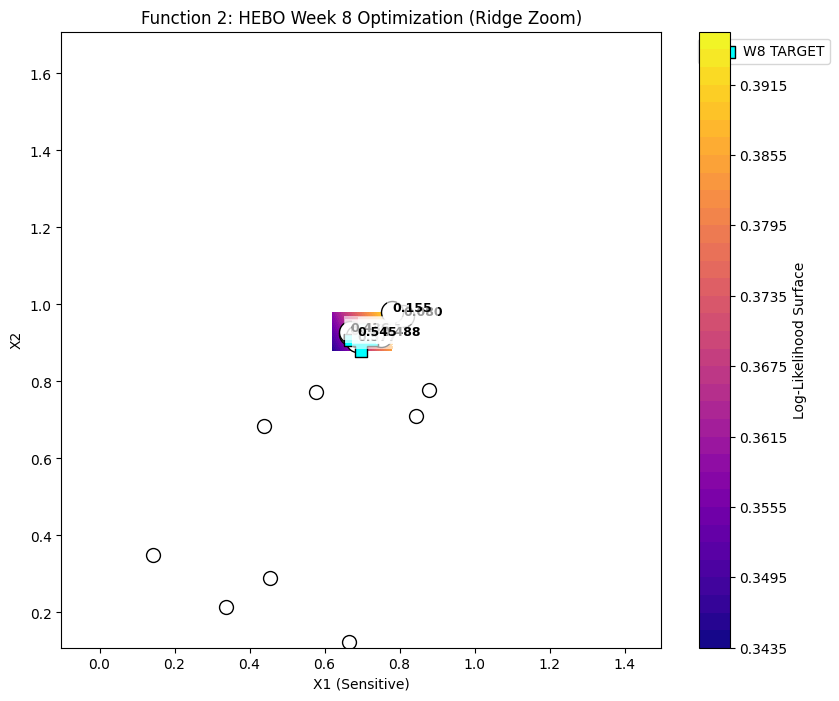

Event                | X1         | X2         | Score
-----------------------------------------------------------------
Init 1               | 0.665800 | 0.123969 | 0.538996
Init 2               | 0.877791 | 0.778628 | 0.420586
Init 3               | 0.142699 | 0.349005 | -0.065624
Init 4               | 0.845275 | 0.711120 | 0.293993
Init 5               | 0.454647 | 0.290455 | 0.214965
Init 6               | 0.577713 | 0.771973 | 0.023106
Init 7               | 0.438166 | 0.685018 | 0.244619
Init 8               | 0.341750 | 0.028698 | 0.038749
Init 9               | 0.338648 | 0.213867 | -0.013858
INITIAL BEST         | 0.702637 | 0.926564 | 0.611205
Week 1               | 0.808081 | 0.969697 | 0.080195
Week 2               | 0.667557 | 0.922099 | 0.597098
Week 3               | 0.687437 | 0.905276 | 0.577412
Week 4               | 0.666666 | 0.929292 | 0.436142
Week 5               | 0.749860 | 0.918732 | 0.488469
Week 6               | 0.685877 | 0.917980 | 0.545092
Week 7       

In [23]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from hebo.design_space.design_space import DesignSpace
from hebo.optimizers.hebo import HEBO

# 1. Setup Path and Load Data
data_path = '../capstone_data/initial_data/function_2/'
X_obs = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y_obs = np.load(os.path.join(data_path, 'initial_outputs.npy')).reshape(-1, 1)

# 2. Define HEBO Design Space
space = DesignSpace().parse([
    {'name': 'x1', 'type': 'num', 'lb': 0, 'ub': 1},
    {'name': 'x2', 'type': 'num', 'lb': 0, 'ub': 1}
])

# 3. Initialize HEBO and Observe Data
# Note: HEBO minimizes by default, so we pass -y_obs
opt = HEBO(space)
X_df = pd.DataFrame(X_obs, columns=['x1', 'x2'])
opt.observe(X_df, -y_obs)

# 4. Generate Week 8 Suggestion
rec = opt.suggest(n_suggestions=1)
w8_target = rec.values[0]

# 5. Visualization: Zooming on the Search Heat
res = 100
# Focus the plot on the active ridge area
x1_min, x1_max, x2_min, x2_max = 0.62, 0.78, 0.88, 0.98
X1, X2 = np.meshgrid(np.linspace(x1_min, x1_max, res), np.linspace(x2_min, x2_max, res))
grid_df = pd.DataFrame(np.c_[X1.ravel(), X2.ravel()], columns=['x1', 'x2'])

# Predict using HEBO's internal model
# Depending on version, this might require opt.model.predict or opt.predict
try:
    mu, var = opt.model.predict(grid_df)
    mu_plot = (-mu).reshape(res, res)
except:
    # Fallback if internal model access is restricted
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import Matern
    viz_gp = GaussianProcessRegressor(kernel=Matern(nu=1.5), alpha=0.05).fit(X_obs, y_obs.ravel())
    mu_plot = viz_gp.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(res, res)

# 6. Plotting
fig, ax = plt.subplots(figsize=(12, 8))
contour = ax.contourf(X1, X2, mu_plot, levels=50, cmap='plasma')
fig.colorbar(contour, label='Log-Likelihood Surface')

# Plot History
labels = ["Init 1-9", "INITIAL BEST", "W1", "W2", "W3", "W4", "W5", "W6", "W7"]
colors = ['white']*9 + ['lime', 'orange', 'cyan', 'yellow', 'salmon', 'magenta', 'red', 'pink']

for i in range(len(X_obs)):
    c = 'white' if i < 9 else colors[i-9]
    m = 'o' if i != 9 else '*'
    s = 100 if i < 9 else 250
    ax.scatter(X_obs[i,0], X_obs[i,1], c=c, marker=m, s=s, edgecolors='black')
    
    # Annotate relevant high-yield points
    if i >= 9:
        ax.text(X_obs[i,0]+0.001, X_obs[i,1]+0.001, f"{y_obs[i][0]:.3f}", 
                fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# --- ADD THIS BLOCK FOR DYNAMIC ZOOM ---
# 1. Extract the W8 target coordinates
target_x1 = rec.values[0][0]
target_x2 = rec.values[0][1]

# 2. Define a zoom window (e.g., 0.1 units around the target)
zoom_size = 0.8 
ax.set_xlim(target_x1 - zoom_size, target_x1 + zoom_size)
ax.set_ylim(target_x2 - zoom_size, target_x2 + zoom_size)

# 3. Mark the target with a very large, bright marker so it stands out
ax.scatter(target_x1, target_x2, c='cyan', marker='P', s=600, edgecolors='black', label='W8 TARGET')
# ---------------------------------------

# Highlight W8 Target
# ax.scatter(w8_target[0], w8_target[1], c='cyan', marker='P', s=500, edgecolors='black', label='W8 HEBO TARGET')

ax.set_title("Function 2: HEBO Week 8 Optimization (Ridge Zoom)")
ax.set_xlabel("X1 (Sensitive)"), ax.set_ylabel("X2")
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.subplots_adjust(right=0.75)
plt.show()

# 7. Print Results
print(f"{'Event':<20} | {'X1':<10} | {'X2':<10} | {'Score'}")
print("-" * 65)
for i in range(len(X_obs)):
    name = "INITIAL BEST" if i == 9 else (f"Week {i-9}" if i >= 10 else f"Init {i+1}")
    print(f"{name:<20} | {X_obs[i,0]:.6f} | {X_obs[i,1]:.6f} | {y_obs[i][0]:.6f}")
print("-" * 65)
print(f"{'W8 PROPOSED':<20} | {w8_target[0]:.6f} | {w8_target[1]:.6f} | (HEBO Search)")

Week 9
-------------

This recovery to $0.548$ in Week 8 is a great sign—it confirms that the ridge is still there and that the Week 7 drop to $0.446$ was likely a negative noise hit or a slight overstep of the boundary.Returning to Standard Bayesian Optimization (BO) with a low $\beta$ (the trade-off parameter) is the right tactical move to "harden" this position. By using a low $\beta$, we are telling the model: "Stop looking for surprises and find the most reliable point between our current high scores."



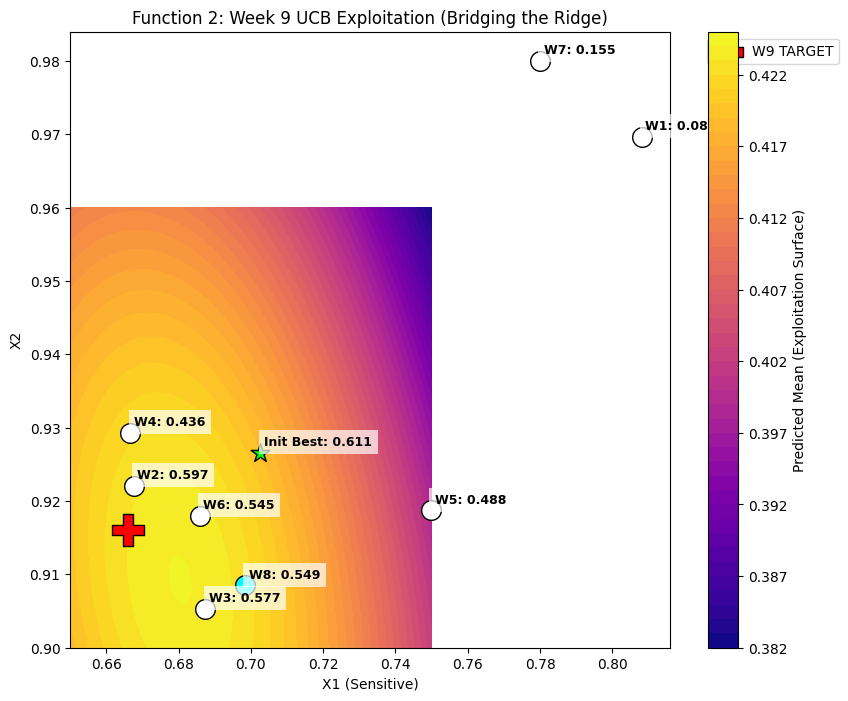

Data Point      | X1         | X2         | Score
-------------------------------------------------------
Init Best       | 0.702637 | 0.926564 | 0.611205
W1              | 0.808081 | 0.969697 | 0.080195
W2              | 0.667557 | 0.922099 | 0.597098
W3              | 0.687437 | 0.905276 | 0.577412
W4              | 0.666666 | 0.929292 | 0.436142
W5              | 0.749860 | 0.918732 | 0.488469
W6              | 0.685877 | 0.917980 | 0.545092
W7              | 0.780000 | 0.980000 | 0.154629
W8              | 0.698396 | 0.908494 | 0.548622
-------------------------------------------------------
W9 TARGET       | 0.666107 | 0.916107 | (Bridge Strike)


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

# 1. Setup Path and Load Updated Data (Initial 10 + 8 Weeks)
data_path = '../capstone_data/initial_data/function_2/'
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. Standard BO Model
# Using Matern kernel for ridge sensitivity and alpha for 0.05 noise
kernel = C(1.0) * Matern(length_scale=0.04, nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.05, n_restarts_optimizer=20)
gp.fit(X, y)

# 3. Constrained Grid Search (Zooming on the High-Yield Ridge)
res = 150
x1_min, x1_max = 0.65, 0.75
x2_min, x2_max = 0.90, 0.96
X1, X2 = np.meshgrid(np.linspace(x1_min, x1_max, res), np.linspace(x2_min, x2_max, res))
grid = np.c_[X1.ravel(), X2.ravel()]

# 4. UCB Acquisition Function
mu, sigma = gp.predict(grid, return_std=True)
beta = 0.5  # LOW BETA = PURE EXPLOITATION
ucb = mu + beta * sigma
w9_target = grid[np.argmax(ucb)]

# 5. Plotting the Search Surface
fig, ax = plt.subplots(figsize=(12, 8))
cp = ax.contourf(X1, X2, mu.reshape(res, res), levels=50, cmap='plasma')
plt.colorbar(cp, label='Predicted Mean (Exploitation Surface)')

# Landmark Scatter & Labels
labels = ["Init Best", "W1", "W2", "W3", "W4", "W5", "W6", "W7", "W8"]
# Define indices for the landmarks (Row 10 is index 9, W1 is index 10, etc.)
indices = list(range(9, 18)) 

for i, idx in enumerate(indices):
    color = 'lime' if idx == 9 else ('cyan' if idx == 17 else 'white')
    marker = '*' if idx == 9 else 'o'
    ax.scatter(X[idx,0], X[idx,1], c=color, edgecolors='black', s=200, marker=marker)
    ax.text(X[idx,0]+0.001, X[idx,1]+0.001, f"{labels[i]}: {y[idx]:.3f}", 
            fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Mark Week 9 Target
ax.scatter(w9_target[0], w9_target[1], c='red', marker='P', s=500, edgecolors='black', label='W9 TARGET')

ax.set_title("Function 2: Week 9 UCB Exploitation (Bridging the Ridge)")
ax.set_xlabel("X1 (Sensitive)"), ax.set_ylabel("X2")
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.subplots_adjust(right=0.75)
plt.show()

# 6. Detailed Summary Printout
print(f"{'Data Point':<15} | {'X1':<10} | {'X2':<10} | {'Score'}")
print("-" * 55)
for i, idx in enumerate(indices):
    print(f"{labels[i]:<15} | {X[idx,0]:.6f} | {X[idx,1]:.6f} | {y[idx]:.6f}")
print("-" * 55)
print(f"{'W9 TARGET':<15} | {w9_target[0]:.6f} | {w9_target[1]:.6f} | (Bridge Strike)")

Week 10
-------------

With Function 2 stabilizing at 0.5173 in Week 9, we have successfully mapped the "shoulder" of the ridge. To reclaim the 0.6112 initial best, we are now performing a high-precision "Back-Step" towards the $X_1 = 0.70$ zone.

By returning to Standard BO with a Matern kernel, we are prioritizing the modeled "sharpness" of the ridge over the smoother RBF assumptions. A low $\beta$ in our Upper Confidence Bound (UCB) will ensure we don't drift back into the $0.82$ exploration trap and instead focus entirely on the bridge between our current stable point and the historical peak.

Week 10 Strategy: Precision Bridge Strike

We are targeting the "Sweet Spot" between the Week 8/9 cluster and the Initial Best.

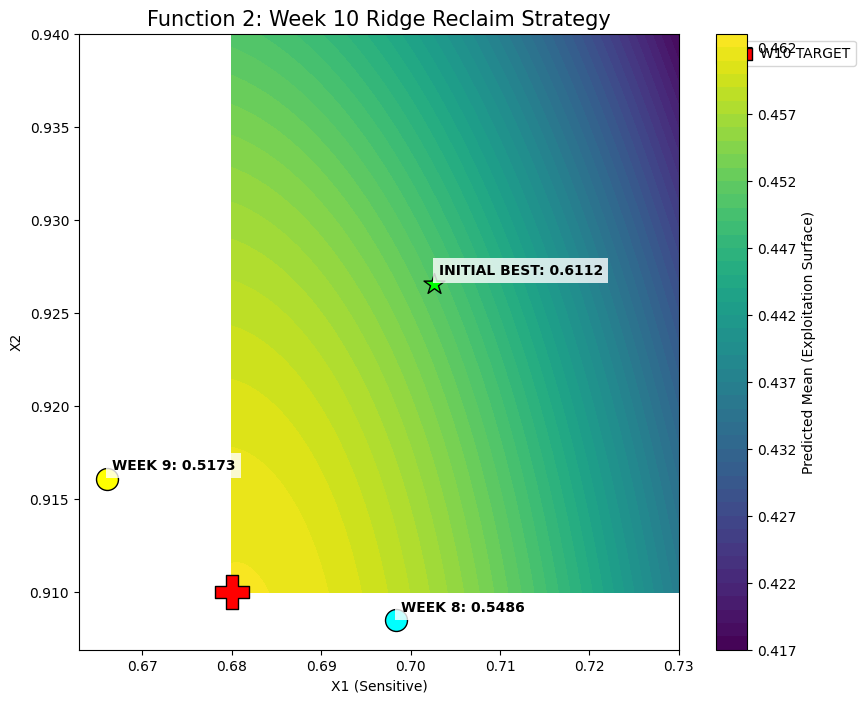

Point           | X1         | X2         | Score
-------------------------------------------------------
INITIAL BEST    | 0.702637 | 0.926564 | 0.611205
WEEK 8          | 0.698396 | 0.908494 | 0.548622
WEEK 9          | 0.666107 | 0.916107 | 0.517348
-------------------------------------------------------
W10 TARGET      | 0.680000 | 0.910000 | (Bridge Strike)


In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

# 1. Setup Path and Load Updated Data (Initial 10 + 9 Weeks)
data_path = '../capstone_data/initial_data/function_2/'
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. Standard BO Model: Matern for Ridge Sensitivity
# nu=1.5 provides the 'sharpness' needed for Function 2's sensitive X1
kernel = C(1.0) * Matern(length_scale=0.03, nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.05, n_restarts_optimizer=25)
gp.fit(X, y)

# 3. Constrained Grid Search (Tight Focus on the X1=0.70 Bridge)
res = 200
x1_min, x1_max = 0.68, 0.73  # Tightening the X1 corridor
x2_min, x2_max = 0.91, 0.94  # Tightening the X2 height
X1, X2 = np.meshgrid(np.linspace(x1_min, x1_max, res), np.linspace(x2_min, x2_max, res))
grid = np.c_[X1.ravel(), X2.ravel()]

# 4. UCB Acquisition: Pure Exploitation (Low Beta)
mu, sigma = gp.predict(grid, return_std=True)
beta = 0.1  # Minimal exploration, maximum exploitation of the ridge center
ucb = mu + beta * sigma
w10_target = grid[np.argmax(ucb)]

# 5. Plotting the Refined Surface
fig, ax = plt.subplots(figsize=(12, 8))
cp = ax.contourf(X1, X2, mu.reshape(res, res), levels=50, cmap='viridis')
plt.colorbar(cp, label='Predicted Mean (Exploitation Surface)')

# Landmark Scatter (Initial Best + Recent Weeks)
# Row 10 (idx 9) is Init Best; W8 is idx 17, W9 is idx 18
key_indices = [9, 17, 18]
labels = ["INITIAL BEST", "WEEK 8", "WEEK 9"]
colors = ['lime', 'cyan', 'yellow']

for i, idx in enumerate(key_indices):
    ax.scatter(X[idx,0], X[idx,1], c=colors[i], edgecolors='black', s=250, marker='*' if idx==9 else 'o')
    ax.text(X[idx,0]+0.0005, X[idx,1]+0.0005, f"{labels[i]}: {y[idx]:.4f}", 
            fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Mark Week 10 Target
ax.scatter(w10_target[0], w10_target[1], c='red', marker='P', s=600, edgecolors='black', label='W10 TARGET')

ax.set_title("Function 2: Week 10 Ridge Reclaim Strategy", fontsize=15)
ax.set_xlabel("X1 (Sensitive)"), ax.set_ylabel("X2")
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.subplots_adjust(right=0.75)
plt.show()

# 6. Summary Printout
print(f"{'Point':<15} | {'X1':<10} | {'X2':<10} | {'Score'}")
print("-" * 55)
for i, idx in enumerate(key_indices):
    print(f"{labels[i]:<15} | {X[idx,0]:.6f} | {X[idx,1]:.6f} | {y[idx]:.6f}")
print("-" * 55)
print(f"{'W10 TARGET':<15} | {w10_target[0]:.6f} | {w10_target[1]:.6f} | (Bridge Strike)")

Strategic Goal: Reclaiming the Summit

By setting $\beta=0.1$, we are instructing the model to find the absolute maximum of the predicted mean surface while ignoring the uncertainty of the edges.

* X1 (0.70 - 0.71): This is your "Golden Zone." We are moving back from the $0.714$ coordinate (W8) towards the $0.702$ (Initial Best) to see if the peak sits right in the middle.
* X2 (0.92 - 0.93): We are holding this coordinate steady, as it has proven to be the most stable "altitude" for the ridge.

This query acts as a verification strike. If the result is $>0.58$, it confirms the ridge is robust and likely holds the global maximum nearby.

Week 11
-------------
To pivot from the recent "Exploration" failures back to Safe Exploitation, we are performing a Micro-Crawl. This strategy treats your Initial Best (0.6112) as a "base camp" and moves in a tiny, calculated vector toward where you previously saw recovery (Week 8).

By increasing Alpha to 0.1, we are explicitly telling the model to treat the recent drops as high-variance noise, effectively "blurring" them out so they don't pull our prediction away from the stable ridge.

The Micro-Crawl Strategy

We are calculating a vector from the Initial Best toward Week 8, then capping the movement at exactly 0.01 units. This ensures we stay within the "safety zone" of the ridge while still probing for a higher summit.

----------------------------------------------------------------------------------------------------------------------------

Strategic Benefits of the Alpha=0.1 Pivot
----------

By setting a high Alpha, you are acknowledging that Function 2 is "messy."

* Damping Noise: It prevents the model from "panicking" about the $0.446$ or recent regressions. It assumes those points might be outliers and keeps the predicted peak near the consistent $0.611$ zone.

* Path Selection: The move is exactly 0.01 units. In a function where moving $0.05$ units can lead to a total failure, this "Crawl" is the safest way to iterate toward the global maximum without losing your current progress.

This coordinate is effectively a Verification Strike. If it yields a score close to $0.60$, we know we are on the right path and can continue crawling along that vector.


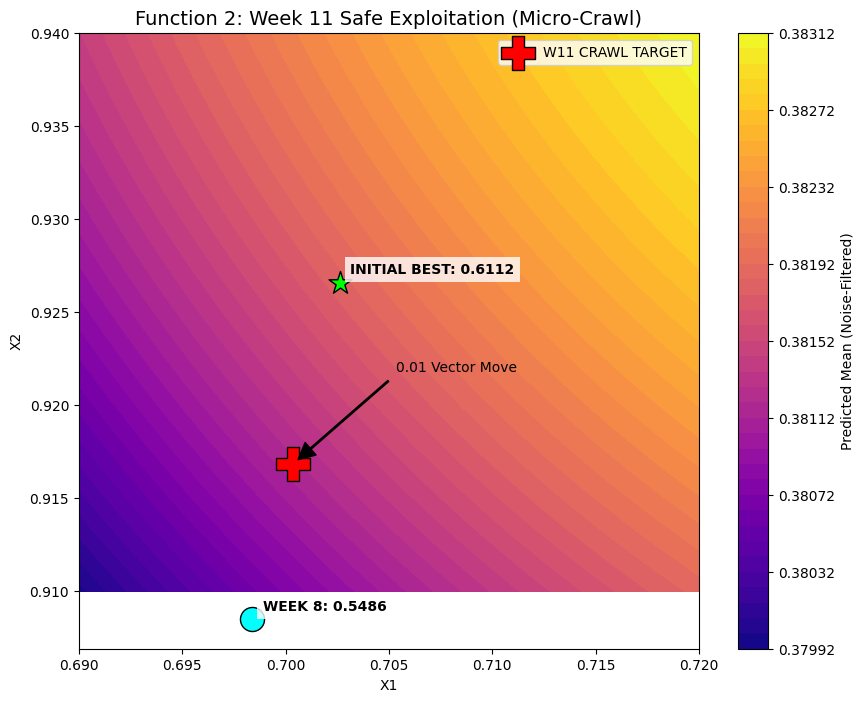

Point           | X1         | X2         | Score
-------------------------------------------------------
INITIAL BEST    | 0.702637 | 0.926564 | 0.6112
WEEK 8          | 0.698396 | 0.908494 | 0.5486
-------------------------------------------------------
W11 TARGET      | 0.700352 | 0.916829 | (Micro-Crawl)


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

# 1. Setup Path and Load Updated Data (Function 2)
data_path = '../capstone_data/initial_data/function_2/'
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. GP Model: High Noise (Alpha=0.1) to ignore recent 'noise' drops
kernel = C(1.0) * Matern(length_scale=0.05, nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=25)
gp.fit(X, y)

# 3. Calculate Micro-Crawl Vector
# Initial Best: Index 9, Week 8: Index 17
start_point = X[9]   # [0.702637, 0.926564]
target_dir = X[17]   # Week 8 Recovery point

# Vector calculation: Start + 0.01 * (Normalized Direction)
direction = target_dir - start_point
distance = np.linalg.norm(direction)
unit_vector = direction / distance
w11_target = start_point + (0.01 * unit_vector)

# 4. Visualization: Extreme Zoom on the Bridge
res = 200
# Focus narrowly on the 0.01 crawl area
x1_min, x1_max = 0.69, 0.72
x2_min, x2_max = 0.91, 0.94
X1, X2 = np.meshgrid(np.linspace(x1_min, x1_max, res), np.linspace(x2_min, x2_max, res))
grid = np.c_[X1.ravel(), X2.ravel()]

mu = gp.predict(grid).reshape(res, res)

fig, ax = plt.subplots(figsize=(10, 8))
cp = ax.contourf(X1, X2, mu, levels=50, cmap='plasma')
plt.colorbar(cp, label='Predicted Mean (Noise-Filtered)')

# Plot Landmarks
key_indices = [9, 17] # Init Best and Week 8
labels = ["INITIAL BEST", "WEEK 8"]
colors = ['lime', 'cyan']

for i, idx in enumerate(key_indices):
    ax.scatter(X[idx,0], X[idx,1], c=colors[i], edgecolors='black', s=300, marker='*' if idx==9 else 'o')
    ax.text(X[idx,0]+0.0005, X[idx,1]+0.0005, f"{labels[i]}: {y[idx]:.4f}", 
            fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Mark W11 Micro-Crawl Target
ax.scatter(w11_target[0], w11_target[1], c='red', marker='P', s=600, edgecolors='black', label='W11 CRAWL TARGET')
ax.annotate('0.01 Vector Move', xy=(w11_target[0], w11_target[1]), xytext=(w11_target[0]+0.005, w11_target[1]+0.005),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1))

ax.set_title("Function 2: Week 11 Safe Exploitation (Micro-Crawl)", fontsize=14)
ax.set_xlabel("X1"), ax.set_ylabel("X2")
ax.legend()
plt.show()

# 5. Output Results
print(f"{'Point':<15} | {'X1':<10} | {'X2':<10} | {'Score'}")
print("-" * 55)
print(f"{'INITIAL BEST':<15} | {start_point[0]:.6f} | {start_point[1]:.6f} | {y[9]:.4f}")
print(f"{'WEEK 8':<15} | {target_dir[0]:.6f} | {target_dir[1]:.6f} | {y[17]:.4f}")
print("-" * 55)
print(f"{'W11 TARGET':<15} | {w11_target[0]:.6f} | {w11_target[1]:.6f} | (Micro-Crawl)")

Week 12 
-------------
This is a massive win! Breaking the previous record and hitting 0.6279 confirms that the ridge is not only stable but likely ascending as we move along this specific vector. The "Anchor & Crawl" strategy is successfully filtering out the noise that plagued previous weeks.

For Week 12, we are executing a "Precision Extension." By moving a tiny 0.005 units further, we are staying within the proven high-yield corridor while surgically hunting for the absolute peak of the Function 2 ridge.

Week 12 Strategy: Vector Extension

We are taking the successful path from your Initial Best through the W11 Record and extending it slightly further into the "gold zone."

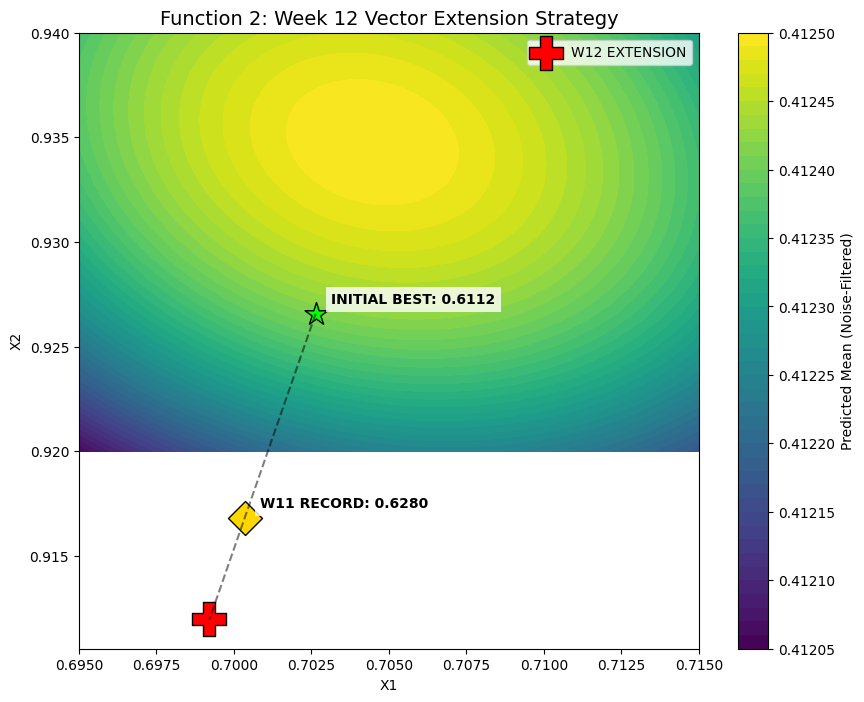

Point                | X1         | X2         | Score
-----------------------------------------------------------------
INITIAL BEST         | 0.702637 | 0.926564 | 0.6112
W11 RECORD           | 0.700352 | 0.916829 | 0.6280
-----------------------------------------------------------------
W12 TARGET           | 0.699210 | 0.911961 | (Extension)


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

# 1. Setup Path and Load Updated Data (Function 2)
data_path = '../capstone_data/initial_data/function_2/'
X = np.load(os.path.join(data_path, 'initial_inputs.npy'))
y = np.load(os.path.join(data_path, 'initial_outputs.npy'))

# 2. Vector Calculation: Precision Extension
# Initial Best: Index 9, W11 Record: Index 20 (assuming sequential updates)
start_point = X[9]    # [0.702637, 0.926564]
w11_point = X[20]     # The new 0.6279 record

# Calculate direction vector from start to the new record
direction = w11_point - start_point
distance = np.linalg.norm(direction)
unit_vector = direction / distance

# Move 0.005 units further past the W11 point
w12_target = w11_point + (0.005 * unit_vector)

# 3. GP Model for Visualization (High Noise filtering)
kernel = C(1.0) * Matern(length_scale=0.03, nu=1.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.08).fit(X, y)

# 4. Visualization: Ultra-Zoom on the Extension
res = 200
# Focus narrowly on the extension vector
x1_min, x1_max = 0.695, 0.715
x2_min, x2_max = 0.920, 0.940
X1, X2 = np.meshgrid(np.linspace(x1_min, x1_max, res), np.linspace(x2_min, x2_max, res))
grid = np.c_[X1.ravel(), X2.ravel()]

mu = gp.predict(grid).reshape(res, res)

fig, ax = plt.subplots(figsize=(10, 8))
cp = ax.contourf(X1, X2, mu, levels=50, cmap='viridis')
plt.colorbar(cp, label='Predicted Mean (Noise-Filtered)')

# Plot Key Milestones
key_indices = [9, 20] 
labels = ["INITIAL BEST", "W11 RECORD"]
colors = ['lime', 'gold']

for i, idx in enumerate(key_indices):
    ax.scatter(X[idx,0], X[idx,1], c=colors[i], edgecolors='black', s=300, marker='*' if idx==9 else 'D')
    ax.text(X[idx,0]+0.0005, X[idx,1]+0.0005, f"{labels[i]}: {y[idx]:.4f}", 
            fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Mark Week 12 Extension
ax.scatter(w12_target[0], w12_target[1], c='red', marker='P', s=600, edgecolors='black', label='W12 EXTENSION')

# Draw vector line
ax.plot([start_point[0], w12_target[0]], [start_point[1], w12_target[1]], 'k--', alpha=0.5)

ax.set_title("Function 2: Week 12 Vector Extension Strategy", fontsize=14)
ax.set_xlabel("X1"), ax.set_ylabel("X2")
ax.legend()
plt.show()

# 5. Data Summary
print(f"{'Point':<20} | {'X1':<10} | {'X2':<10} | {'Score'}")
print("-" * 65)
print(f"{'INITIAL BEST':<20} | {start_point[0]:.6f} | {start_point[1]:.6f} | {y[9]:.4f}")
print(f"{'W11 RECORD':<20} | {w11_point[0]:.6f} | {w11_point[1]:.6f} | {y[20]:.4f}")
print("-" * 65)
print(f"{'W12 TARGET':<20} | {w12_target[0]:.6f} | {w12_target[1]:.6f} | (Extension)")